Fitted parameters: A = 141.49055522344682, B = 13.071111602270229
R² of the fit: 0.21734501311043652


/var/folders/m1/ws2562m105bdpyh7s345x7cw0000gn/T/ipykernel_94560/1211042408.py:9: RuntimeWarning: invalid value encountered in power
  return A * B ** (-wb)


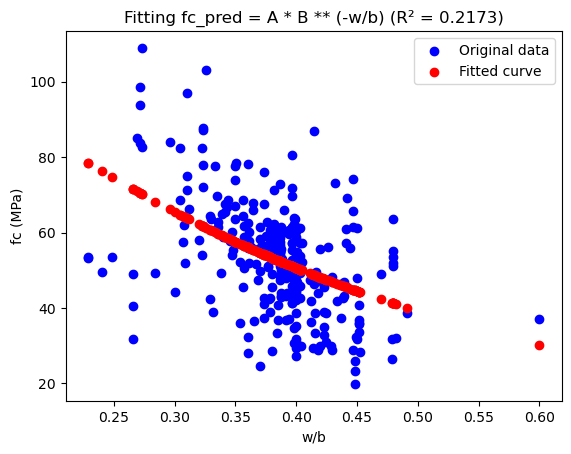

In [18]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define the equation
def equation(wb, A, B):
    return A * B ** (-wb)

# Load the dataset
filename = 'Rapid_set.xlsx'
sheetname = 'age56'
df = pd.read_excel(filename, sheet_name=sheetname)

# Extract the features ('w/b' and 'fc (MPa)')
wb = df['w/b'].values  # Assuming 'w/b' is the column for 'w/b'
fc = df['fc (MPa)'].values  # Assuming 'fc (MPa)' is the column for compressive strength

# Fit the curve
params, covariance = curve_fit(equation, wb, fc)

# Extract the fitted parameters
A, B = params
print(f"Fitted parameters: A = {A}, B = {B}")

# Predict the compressive strength using the fitted equation
fc_pred = equation(wb, A, B)

# Calculate R²
r2 = r2_score(fc, fc_pred)
print(f"R² of the fit: {r2}")

# Plot the original data and the fitted curve
plt.scatter(wb, fc, label='Original data', color='blue')
plt.scatter(wb, fc_pred, label='Fitted curve', color='red')
plt.xlabel('w/b')
plt.ylabel('fc (MPa)')
plt.title(f'Fitting fc_pred = A * B ** (-w/b) (R² = {r2:.4f})')
plt.legend()
plt.show()


R² of the linear fit with transformed w/b term: 0.49463853453696327
Model coefficients: [ 6.86083077e+02  1.21930568e-01  3.65164991e-01  1.19184057e-01
  1.31260979e-01  1.64223721e-01 -2.28908811e-03 -1.47406959e-03
 -2.16773976e-01 -3.01428698e-01  3.10069936e-02  2.73067246e-03
  2.80926094e-03 -2.46730264e-01 -3.56841095e+01  2.37568956e-01
 -2.37568956e-01]
Model intercept: -691.4738224184479


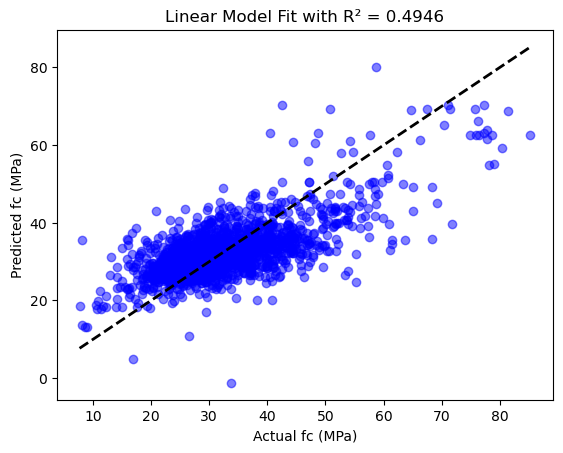

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset
filename = 'normal.xlsx'
sheetname = 'age7'
df = pd.read_excel(filename, sheet_name=sheetname)

# Transform w/b using m**(w/b)
m = 1.1  # This is a hyperparameter you might want to tune.
df['transformed_wb'] = m ** df['w/b']  # Transform w/b

# Define the features and target
X = df[['transformed_wb', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
        'WR_HR', 'WR', 'ACC', 'VOID', 'b/a', 'CAGG%', 'FAGG%']].values  # add all other features
y = df['fc (MPa)'].values  # Target

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict the compressive strength using the model
y_pred = model.predict(X)

# Calculate R² for the fit
r2 = r2_score(y, y_pred)
print(f"R² of the linear fit with transformed w/b term: {r2}")

# Optional: Print the coefficients
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

# Plotting the predictions vs. actual values
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual fc (MPa)')
plt.ylabel('Predicted fc (MPa)')
plt.title(f'Linear Model Fit with R² = {r2:.4f}')
plt.show()


R² of the linear fit with transformed w/b term: 0.48111150119726787

Fitted Equation:
fc (MPa) = -89.58 + (115.75 * transformed_wb) + (0.09 * PC) + (0.38 * PC_TYPE) + (0.11 * FA) + (0.12 * SS) + (0.20 * SF) + (0.00 * FAGG) + (-0.01 * CAGG) + (-0.13 * WATER) + (-0.28 * AEA) + (0.03 * WR_HR) + (0.00 * WR) + (0.01 * ACC) + (-0.08 * VOID) + (-36.90 * b/a) + (11.48 * CAGG%) + (-11.48 * FAGG%) 


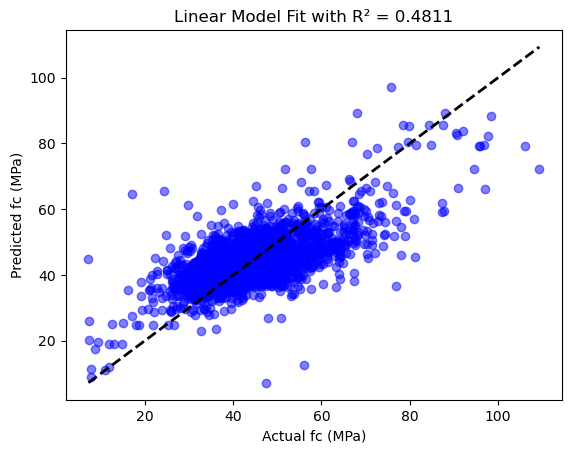

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset
filename = 'normal.xlsx'
sheetname = 'age28'
df = pd.read_excel(filename, sheet_name=sheetname)

# Transform w/b using m**(w/b)
m = 1.1  # Hyperparameter, can be tuned if needed
df['transformed_wb'] = m ** df['w/b']

# Define the features and target
features = ['transformed_wb', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'b/a', 'CAGG%', 'FAGG%']
X = df[features].values
y = df['fc (MPa)'].values

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict the compressive strength
y_pred = model.predict(X)

# Calculate R² for the fit
r2 = r2_score(y, y_pred)
print(f"R² of the linear fit with transformed w/b term: {r2}")

# Print the equation of the fitted model
intercept = model.intercept_
equation = f"fc (MPa) = {intercept:.2f} "

for coef, feature in zip(model.coef_, features):
    equation += f"+ ({coef:.2f} * {feature}) "

print("\nFitted Equation:")
print(equation)

# Plot predictions vs. actual values
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual fc (MPa)')
plt.ylabel('Predicted fc (MPa)')
plt.title(f'Linear Model Fit with R² = {r2:.4f}')
plt.show()


R² of the fit with normalized data: 0.483685947028345

Fitted Equation with Normalized Data:
fc (MPa) = 12145818759505346.00 + (156.08 * transformed_wb) + (0.09 * PC) + (0.39 * PC_TYPE) + (0.11 * FA) + (0.12 * SS) + (0.20 * SF) + (0.00 * FAGG) + (-0.01 * CAGG) + (-0.14 * WATER) + (-0.26 * AEA) + (0.03 * WR_HR) + (0.00 * WR) + (0.01 * ACC) + (-0.11 * VOID) + (-35.12 * b/a) + (-12145818759505468.00 * CAGG%) + (-12145818759505486.00 * FAGG%) 


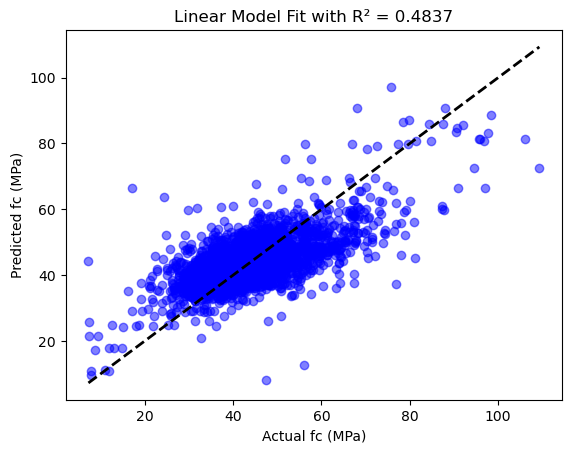

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset
filename = 'normal.xlsx'
sheetname = 'age28'
df = pd.read_excel(filename, sheet_name=sheetname)

# Transform w/b using m**(w/b)
m = 1.1  # Hyperparameter
df['transformed_wb'] = m ** df['w/b']

# Define features and target
features = ['transformed_wb', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'b/a', 'CAGG%', 'FAGG%']
X = df[features].values
y = df['fc (MPa)'].values

# Normalize the features and target
x_mean, x_std = X.mean(axis=0), X.std(axis=0)
X_normal = (X - x_mean) / x_std

y_mean, y_std = y.mean(), y.std()
y_normal = (y - y_mean) / y_std

# Fit the normalized data
model = LinearRegression()
model.fit(X_normal, y_normal)

# Predict the normalized target
y_pred_normal = model.predict(X_normal)

# Rescale predictions back to the original scale
y_pred = y_pred_normal * y_std + y_mean

# Calculate R² for the fit
r2 = r2_score(y, y_pred)
print(f"R² of the fit with normalized data: {r2}")

# Print the equation of the fitted model with normalized coefficients
intercept = model.intercept_ * y_std + y_mean - np.dot(model.coef_, x_mean / x_std) * y_std
equation = f"fc (MPa) = {intercept:.2f} "

for coef, feature, mean, std in zip(model.coef_ * y_std / x_std, features, x_mean, x_std):
    equation += f"+ ({coef:.2f} * {feature}) "

print("\nFitted Equation with Normalized Data:")
print(equation)

# Plot predictions vs. actual values
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual fc (MPa)')
plt.ylabel('Predicted fc (MPa)')
plt.title(f'Linear Model Fit with R² = {r2:.4f}')
plt.show()


Fitted parameters (normalized): A = 0.11374715444034042, B = 3.2283469891684065
R² of the fit: 0.20518030485363214


/var/folders/m1/ws2562m105bdpyh7s345x7cw0000gn/T/ipykernel_94560/3954590451.py:9: RuntimeWarning: invalid value encountered in power
  return A * B ** (-wb)


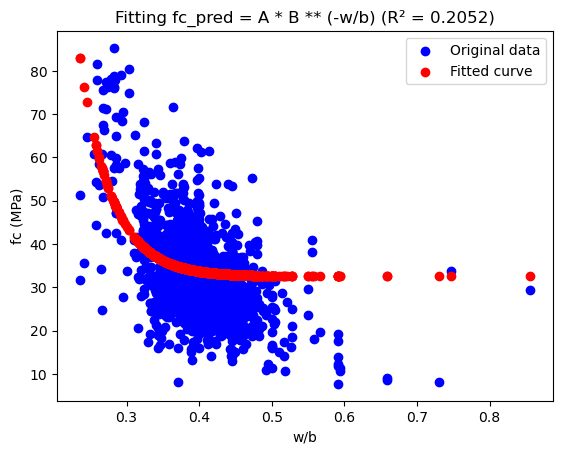

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define the equation
def equation(wb, A, B):
    return A * B ** (-wb)

# Load the dataset
filename = 'normal.xlsx'
sheetname = 'age7'
df = pd.read_excel(filename, sheet_name=sheetname)

# Extract the features ('w/b' and 'fc (MPa)')
wb = df['w/b'].values  # Assuming 'w/b' is the column for 'w/b'
fc = df['fc (MPa)'].values  # Assuming 'fc (MPa)' is the column for compressive strength

# Normalize the data
wb_mean, wb_std = wb.mean(), wb.std()
fc_mean, fc_std = fc.mean(), fc.std()
wb_normalized = (wb - wb_mean) / wb_std
fc_normalized = (fc - fc_mean) / fc_std

# Fit the curve on normalized data
params, covariance = curve_fit(equation, wb_normalized, fc_normalized)

# Extract the fitted parameters
A, B = params
print(f"Fitted parameters (normalized): A = {A}, B = {B}")

# Predict the normalized compressive strength using the fitted equation
fc_pred_normalized = equation(wb_normalized, A, B)

# Convert predictions back to the original scale
fc_pred = fc_pred_normalized * fc_std + fc_mean

# Calculate R²
r2 = r2_score(fc, fc_pred)
print(f"R² of the fit: {r2}")

# Plot the original data and the fitted curve
plt.scatter(wb, fc, label='Original data', color='blue')
plt.scatter(wb, fc_pred, label='Fitted curve', color='red')
plt.xlabel('w/b')
plt.ylabel('fc (MPa)')
plt.title(f'Fitting fc_pred = A * B ** (-w/b) (R² = {r2:.4f})')
plt.legend()
plt.show()


R² of the fit with normalized data: 0.5310954809610199

Fitted Equation with Normalized Data:
Normalized fc (MPa) = 0.00 + (-0.03 * transformed_wb) + (0.43 * PC) + (0.09 * PC_TYPE) + (0.55 * FA) + (0.81 * SS) + (0.09 * SF) + (-0.02 * FAGG) + (0.45 * CAGG) + (-0.16 * WATER) + (-0.15 * AEA) + (0.03 * WR_HR) + (0.08 * WR) + (-0.06 * ACC) + (-0.07 * VOID) + (0.19 * b/a) + (-1750708307108.76 * CAGG%) + (-1750708307108.43 * FAGG%) 


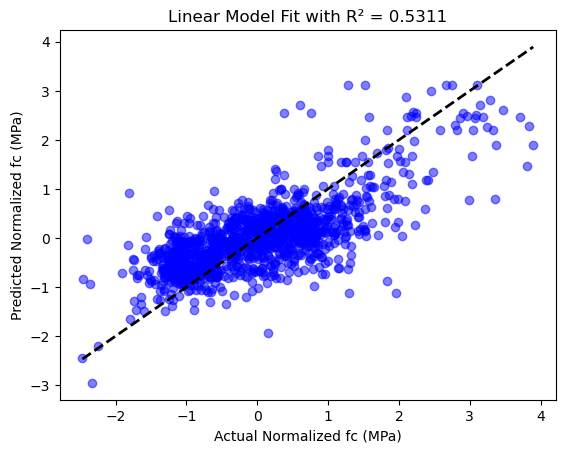

In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset
filename = 'all.xlsx'
sheetname = 'age56'
df = pd.read_excel(filename, sheet_name=sheetname)

# Transform w/b using m**(w/b)
m = 1.1  # Hyperparameter
df['transformed_wb'] = m ** df['w/b']

# Define features and target
features = ['transformed_wb', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'b/a', 'CAGG%', 'FAGG%']
X = df[features].values
y = df['fc (MPa)'].values

# Normalize the features and target
x_mean, x_std = X.mean(axis=0), X.std(axis=0)
X_normal = (X - x_mean) / x_std

# print(X_normal)

y_mean, y_std = y.mean(), y.std()
y_normal = (y - y_mean) / y_std

# Fit the normalized data
model = LinearRegression()
model.fit(X_normal, y_normal)

# Predict the normalized target
y_pred_normal = model.predict(X_normal)

# Calculate R² for the fit
r2 = r2_score(y_normal, y_pred_normal)
print(f"R² of the fit with normalized data: {r2}")

# Print the equation of the fitted model with normalized coefficients
intercept = model.intercept_
equation = f"Normalized fc (MPa) = {intercept:.2f} "

for coef, feature in zip(model.coef_, features):
    equation += f"+ ({coef:.2f} * {feature}) "

print("\nFitted Equation with Normalized Data:")
print(equation)

# Plot predictions vs. actual normalized values
plt.scatter(y_normal, y_pred_normal, color='blue', alpha=0.5)
plt.plot([y_normal.min(), y_normal.max()], [y_normal.min(), y_normal.max()], 'k--', lw=2)
plt.xlabel('Actual Normalized fc (MPa)')
plt.ylabel('Predicted Normalized fc (MPa)')
plt.title(f'Linear Model Fit with R² = {r2:.4f}')
plt.show()


R² of the fit with normalized data: 0.4654821659187496

Fitted Equation with Normalized Data:
Normalized fc (MPa) = 0.01 + (0.04 * transformed_wb) + (0.42 * AGE) + (1.10 * PC) + (0.12 * PC_TYPE) + (0.57 * FA) + (1.00 * SS) + (0.10 * SF) + (-0.15 * FAGG) + (0.17 * CAGG) + (-0.09 * WATER) + (-0.15 * AEA) + (-0.05 * WR_HR) + (0.22 * WR) + (0.08 * ACC) + (-0.03 * VOID) + (-0.19 * b/a) + (-15494526280728.41 * CAGG%) + (-15494526280728.23 * FAGG%) 


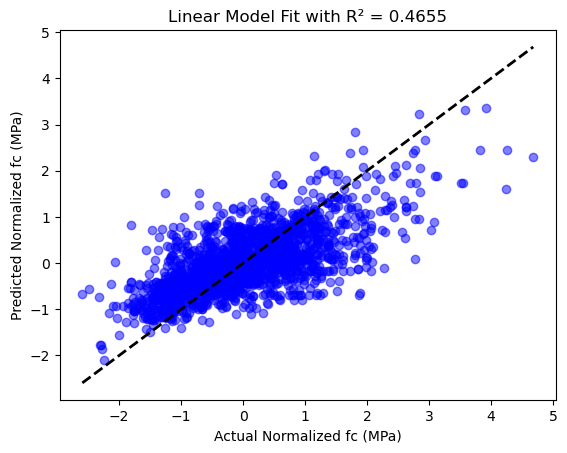

In [35]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the dataset
filename = 'Rapid_set.xlsx'
sheetname = 'rapid_set'
df = pd.read_excel(filename, sheet_name=sheetname)

# Transform w/b using m**(w/b)
m = 1.1  # Hyperparameter
df['transformed_wb'] = m ** df['w/b']

# Define features and target
features = ['transformed_wb','AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'b/a', 'CAGG%', 'FAGG%']
X = df[features].values
y = df['fc (MPa)'].values

# Normalize the features and target
x_mean, x_std = X.mean(axis=0), X.std(axis=0)
X_normal = (X - x_mean) / x_std

# print(X_normal)

y_mean, y_std = y.mean(), y.std()
y_normal = (y - y_mean) / y_std

# Fit the normalized data
model = LinearRegression()
model.fit(X_normal, y_normal)

# Predict the normalized target
y_pred_normal = model.predict(X_normal)

# Calculate R² for the fit
r2 = r2_score(y_normal, y_pred_normal)
print(f"R² of the fit with normalized data: {r2}")

# Print the equation of the fitted model with normalized coefficients
intercept = model.intercept_
equation = f"Normalized fc (MPa) = {intercept:.2f} "

for coef, feature in zip(model.coef_, features):
    equation += f"+ ({coef:.2f} * {feature}) "

print("\nFitted Equation with Normalized Data:")
print(equation)

# Plot predictions vs. actual normalized values
plt.scatter(y_normal, y_pred_normal, color='blue', alpha=0.5)
plt.plot([y_normal.min(), y_normal.max()], [y_normal.min(), y_normal.max()], 'k--', lw=2)
plt.xlabel('Actual Normalized fc (MPa)')
plt.ylabel('Predicted Normalized fc (MPa)')
plt.title(f'Linear Model Fit with R² = {r2:.4f}')
plt.show()
